# Lab Segmentation 1

In [2]:
from commonfunctions import *
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
## For all requirements: The quality of the results is evaluated.


# 1- Read the image 
# [VERY IMPORTANT] and convert it to float: image = image.astype(float)

# read image golf



# 2- Retreive the 3 channels of the image(R,G,B) (will be used in the coming steps)


# 3- Visually (not by code) detect the dominating color channel (C) for the backgroung (R, G or B)

# 4- Draw the dominating channel (r, g or b) thresholded by some threshold (to make sure your choice is meaningful)


# 5- Get an intuitive way(There is a very simple way) to make a mask that can get the pixels where the values of the dominating channels 
# have larger values than the other channels with an appropriate threshold

# 6- display the binarized image






Image shape: (853, 1280, 3)
Image dtype: float64

Visually inspecting channels...
Background is GREEN grass → Green channel dominates


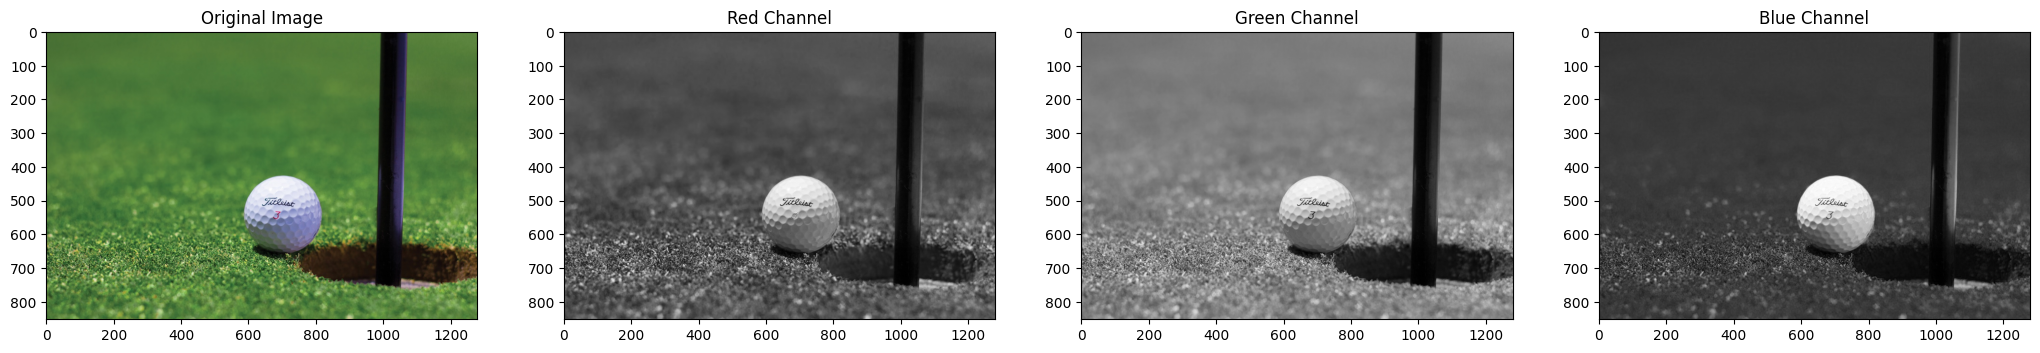

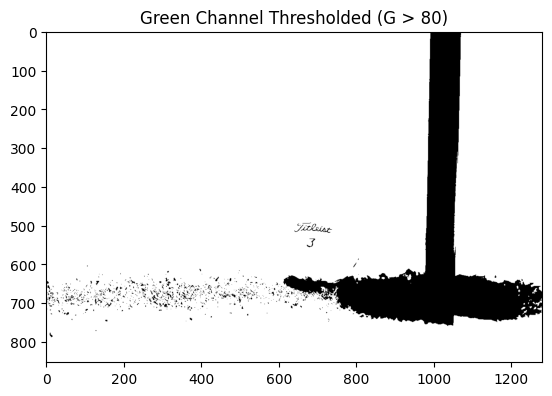


Foreground pixels: 151565
Background pixels: 940275


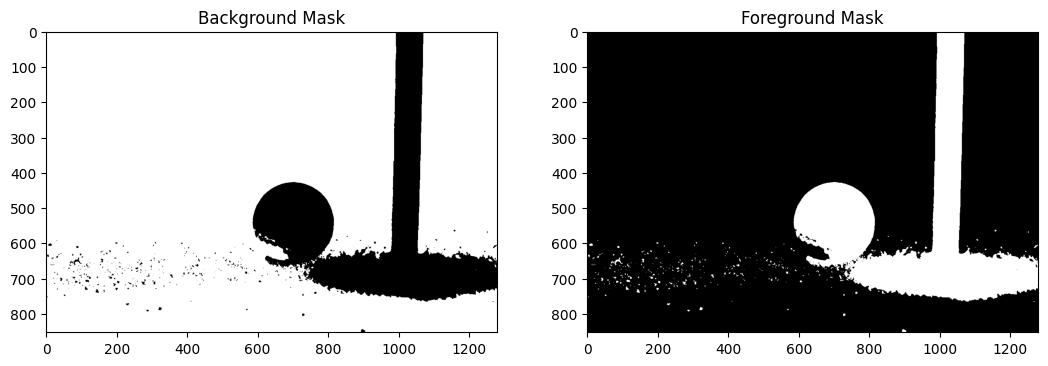

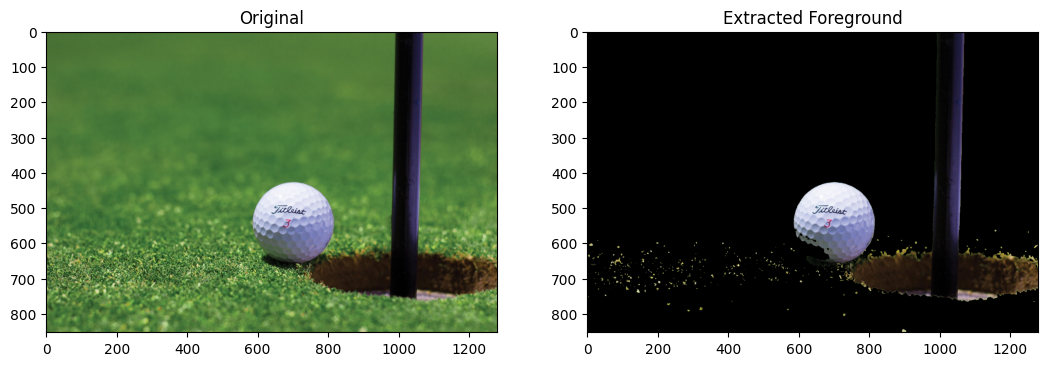

In [6]:

# Step 1: Read the image and convert to float
golf_image = io.imread('imgs/exp1/golf.jpeg')
golf_image = golf_image.astype(float)

print(f"Image shape: {golf_image.shape}")
print(f"Image dtype: {golf_image.dtype}")

# Step 2: Retrieve the 3 channels of the image (R, G, B)
R = golf_image[:, :, 0]
G = golf_image[:, :, 1]
B = golf_image[:, :, 2]

# Step 3: Visually detect the dominating color channel
# The background is GREEN grass, so G channel dominates
print("\nVisually inspecting channels...")
print("Background is GREEN grass → Green channel dominates")

# Step 4: Draw the dominating channel thresholded
threshold = 80
thresholded_green = G > threshold

# Display all channels
show_images([golf_image.astype(np.uint8), R, G, B],
            ['Original Image', 'Red Channel', 'Green Channel', 'Blue Channel'])

# Display thresholded green channel
show_images([thresholded_green], 
            [f'Green Channel Thresholded (G > {threshold})'])

# Step 5: Create mask where Green dominates over other channels
# For grass background: G > R and G > B
margin = 10  # threshold margin
background_mask = (G > R + margin) & (G > B + margin)

# Invert to get foreground
foreground_mask = ~background_mask

print(f"\nForeground pixels: {np.sum(foreground_mask)}")
print(f"Background pixels: {np.sum(background_mask)}")

# Step 6: Display the binarized image
show_images([background_mask, foreground_mask],
            ['Background Mask', 'Foreground Mask'])

# Apply mask to get foreground only
foreground_result = golf_image.copy()
foreground_result[background_mask] = 0  # Set background to black

show_images([golf_image.astype(np.uint8), foreground_result.astype(np.uint8)],
            ['Original', 'Extracted Foreground'])

EXPERIMENT 1: Extracting Foreground from Golf Image (IMPROVED)
Image shape: (853, 1280, 3)
Image dtype: float64

Visually inspecting channels...
Background is GREEN grass → Green channel dominates


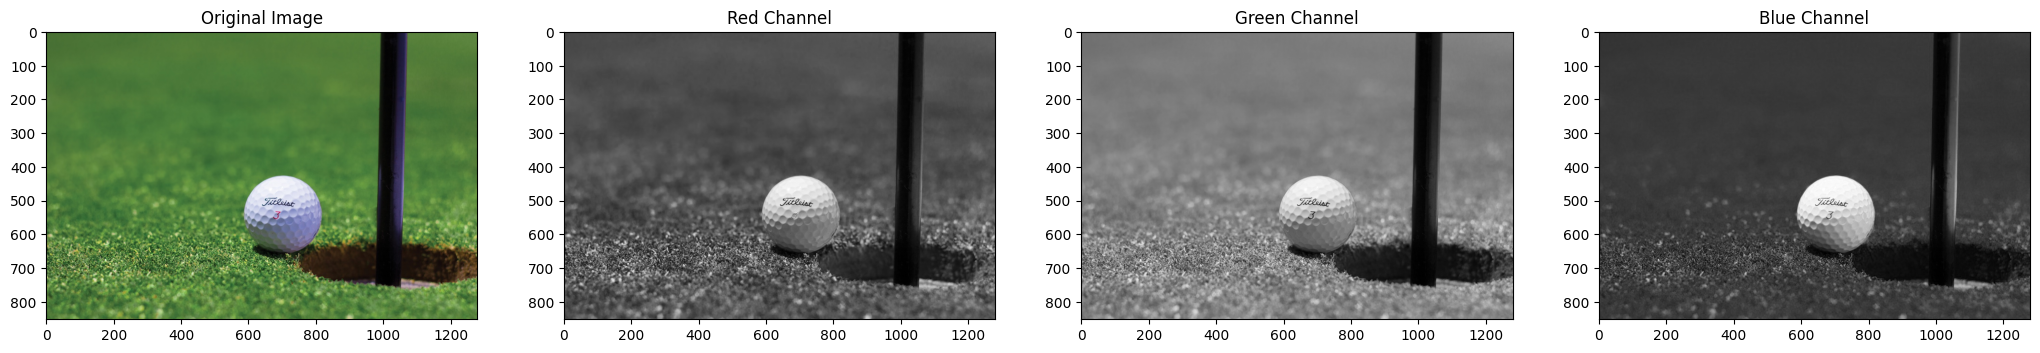

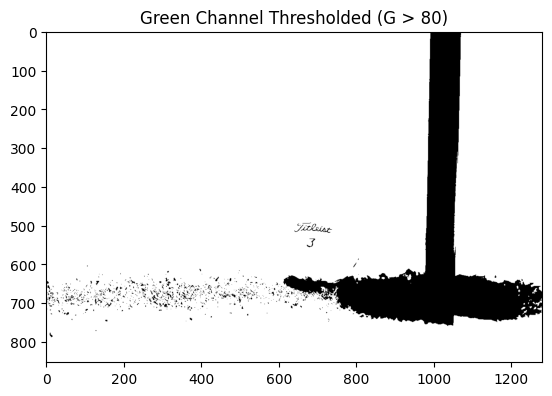


Foreground pixels: 165504
Background pixels: 926336


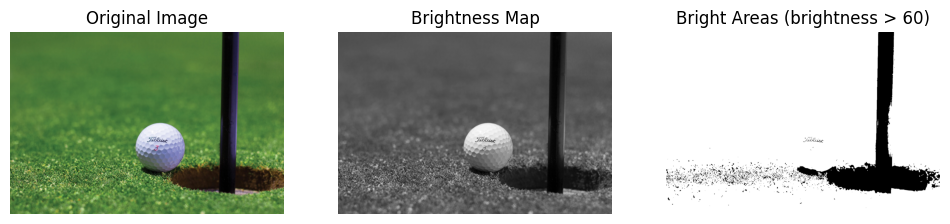

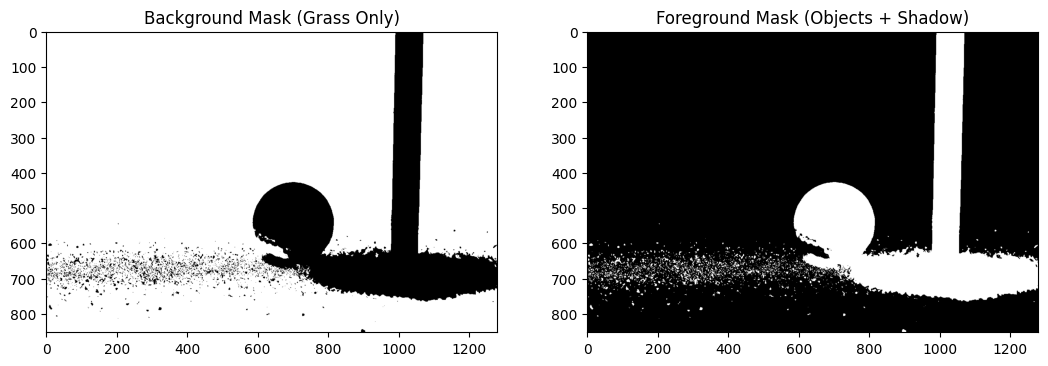

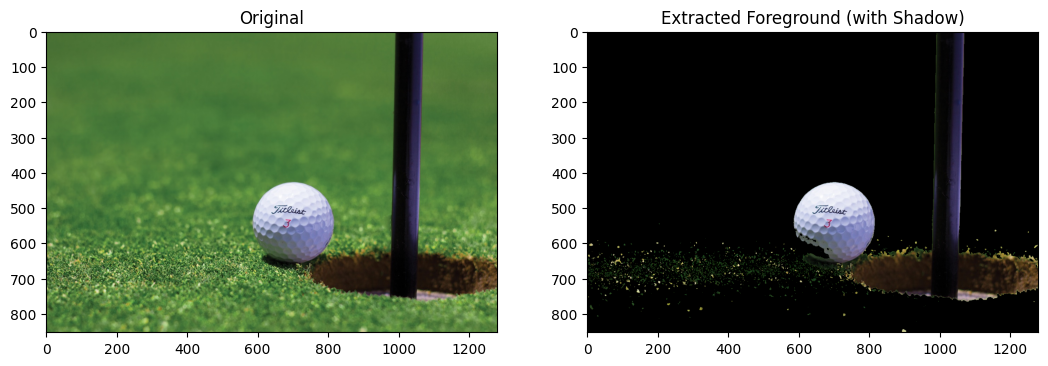

✓ Experiment 1 completed!

Key improvement: Added brightness threshold = 60
This excludes dark shadows from being classified as background grass.


In [12]:
# ==========================================
# EXPERIMENT 1: Golf Ball Foreground Extraction (IMPROVED)
# ==========================================
print("="*50)
print("EXPERIMENT 1: Extracting Foreground from Golf Image (IMPROVED)")
print("="*50)

# Step 1: Read the image and convert to float
golf_image = io.imread('imgs/exp1/golf.jpeg')
golf_image = golf_image.astype(float)

print(f"Image shape: {golf_image.shape}")
print(f"Image dtype: {golf_image.dtype}")

# Step 2: Retrieve the 3 channels of the image (R, G, B)
R = golf_image[:, :, 0]
G = golf_image[:, :, 1]
B = golf_image[:, :, 2]

# Step 3: Visually detect the dominating color channel
print("\nVisually inspecting channels...")
print("Background is GREEN grass → Green channel dominates")

# Step 4: Draw the dominating channel thresholded
threshold = 80
thresholded_green = G > threshold

# Display all channels
show_images([golf_image.astype(np.uint8), R, G, B],
            ['Original Image', 'Red Channel', 'Green Channel', 'Blue Channel'])

# Display thresholded green channel
show_images([thresholded_green], 
            [f'Green Channel Thresholded (G > {threshold})'])

# Step 5: Create mask where Green dominates over other channels
# IMPROVED: Add brightness condition to exclude shadows
margin = 10  # threshold margin
brightness_threshold = 60  # Minimum brightness to be considered grass (not shadow)

# Calculate overall brightness (average of RGB)
brightness = (R + G + B) / 3.0

# Background = Green dominates AND pixel is bright enough (not shadow)
background_mask = (G > R + margin) & (G > B + margin) & (brightness > brightness_threshold)

# Invert to get foreground
foreground_mask = ~background_mask

print(f"\nForeground pixels: {np.sum(foreground_mask)}")
print(f"Background pixels: {np.sum(background_mask)}")

# Visualize brightness to help understand the shadow issue
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(golf_image.astype(np.uint8))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(brightness, cmap='gray')
plt.title('Brightness Map')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(brightness > brightness_threshold, cmap='gray')
plt.title(f'Bright Areas (brightness > {brightness_threshold})')
plt.axis('off')
plt.show()

# Step 6: Display the binarized image
show_images([background_mask, foreground_mask],
            ['Background Mask (Grass Only)', 'Foreground Mask (Objects + Shadow)'])

# Apply mask to get foreground only
foreground_result = golf_image.copy()
foreground_result[background_mask] = 0  # Set background to black

show_images([golf_image.astype(np.uint8), foreground_result.astype(np.uint8)],
            ['Original', 'Extracted Foreground (with Shadow)'])

print("✓ Experiment 1 completed!")
print(f"\nKey improvement: Added brightness threshold = {brightness_threshold}")
print("This excludes dark shadows from being classified as background grass.")

In [ ]:
# 1- Get the required RGB color (Using a color picker)


# 2- Read image

# 3- extract R, G and B channels (as float)

# 4- calculate differences FOR EACH CHANNEL (between the image and the required pixel value)

# 5- calculate overall distance from the given RGB color (use any appropriate distance measure, take care of the minus distances)

# 6-  create a mask by thresholding the differences

# 7- In the input image, Replace the pixels of the mask with the following color
# R = 230 , G = 90 , B=40

# 8- show the image or save it



EXPERIMENT 2: Grass Color Replacement (IMPROVED)

Target grass color: RGB(85, 103, 43)
CUFE Image shape: (279, 620, 3)

Distance map computed
Min distance: 0.00
Max distance: 311.36

Threshold: 40
Pixels matching grass color: 13089
Percentage of image: 7.57%


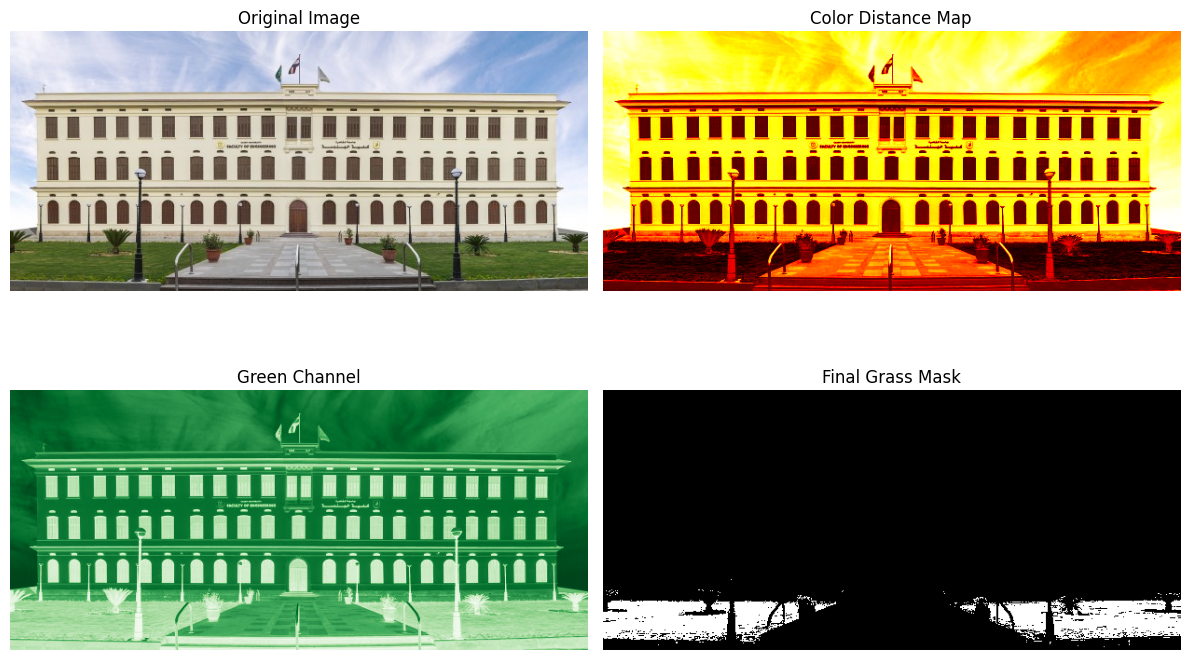


Replacement color: RGB(230, 90, 40)


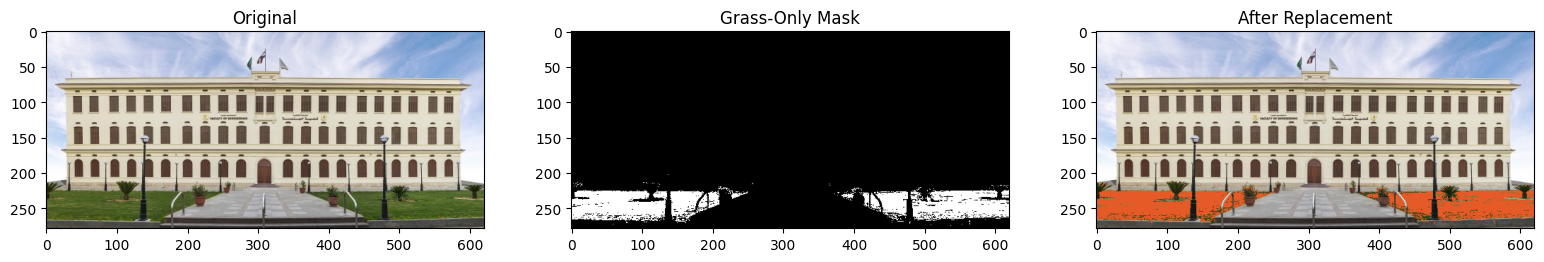


✓ Result saved as 'cufe_modified.jpg'

✓ Experiment 2 completed!


In [9]:
# ==========================================
# EXPERIMENT 2: Color Replacement in CUFE Image (IMPROVED)
# ==========================================
print("\n" + "="*50)
print("EXPERIMENT 2: Grass Color Replacement (IMPROVED)")
print("="*50)

# Step 1: Get the required RGB color (Using a color picker)
target_R = 85
target_G = 103
target_B = 43

print(f"\nTarget grass color: RGB({target_R}, {target_G}, {target_B})")

# Step 2: Read image
cufe_image = io.imread('imgs/exp2/cufe.png')
cufe_image = cufe_image.astype(float)

print(f"CUFE Image shape: {cufe_image.shape}")

# Step 3: Extract R, G and B channels (as float)
R_cufe = cufe_image[:, :, 0]
G_cufe = cufe_image[:, :, 1]
B_cufe = cufe_image[:, :, 2]

# Step 4: Calculate differences FOR EACH CHANNEL
diff_R = R_cufe - target_R
diff_G = G_cufe - target_G
diff_B = B_cufe - target_B

# Step 5: Calculate overall distance from the given RGB color
distance = np.sqrt(diff_R**2 + diff_G**2 + diff_B**2)

print(f"\nDistance map computed")
print(f"Min distance: {np.min(distance):.2f}")
print(f"Max distance: {np.max(distance):.2f}")

# Step 6: Create a MORE SELECTIVE mask
# Combine multiple conditions to isolate ONLY grass:
# 1. Color distance should be small
# 2. Green channel should dominate (grass is green!)
# 3. Pixels should be dark enough (not sky or bright areas)

color_threshold = 40  # Stricter threshold
grass_mask = (distance < color_threshold) & \
             (G_cufe > R_cufe) & \
             (G_cufe > B_cufe) & \
             (G_cufe > 80) & (G_cufe < 120)  # Grass green range

print(f"\nThreshold: {color_threshold}")
print(f"Pixels matching grass color: {np.sum(grass_mask)}")
print(f"Percentage of image: {100 * np.sum(grass_mask) / grass_mask.size:.2f}%")

# Display intermediate results for tuning
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(cufe_image.astype(np.uint8))
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(distance, cmap='hot')
axes[0, 1].set_title('Color Distance Map')
axes[0, 1].axis('off')

axes[1, 0].imshow(G_cufe, cmap='Greens')
axes[1, 0].set_title('Green Channel')
axes[1, 0].axis('off')

axes[1, 1].imshow(grass_mask, cmap='gray')
axes[1, 1].set_title('Final Grass Mask')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

# Step 7: Replace the pixels of the mask with the following color
replacement_R = 230
replacement_G = 90
replacement_B = 40

print(f"\nReplacement color: RGB({replacement_R}, {replacement_G}, {replacement_B})")

result_image = cufe_image.copy()
result_image[grass_mask, 0] = replacement_R
result_image[grass_mask, 1] = replacement_G
result_image[grass_mask, 2] = replacement_B

# Step 8: Show the image or save it
show_images([cufe_image.astype(np.uint8), 
             grass_mask, 
             result_image.astype(np.uint8)],
            ['Original', 'Grass-Only Mask', 'After Replacement'])

# Save the result
io.imsave('cufe_modified.jpg', result_image.astype(np.uint8))
print("\n✓ Result saved as 'cufe_modified.jpg'")

print("\n✓ Experiment 2 completed!")